In [11]:
import pandas as pd, matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [3]:
# 데이터 수집

wine = pd.read_csv("https://bit.ly/wine_csv_data")

# X(data, feature)와  y(target, label)로 나누는 과정
data = wine[["alcohol", "sugar", "pH"]].to_numpy()
target = wine["class"].to_numpy()  # 0=red, 1=white

In [4]:
wine.head(3)

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0


In [5]:
wine.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [6]:
wine.columns

Index(['alcohol', 'sugar', 'pH', 'class'], dtype='str')

In [7]:
# train, test 나누가
train_input, test_input, train_target, test_target = train_test_split(
    data, target, test_size=0.2, random_state=42
)

In [8]:
# StandardScale
scale = StandardScaler()
train_scaled = scale.fit_transform(train_input)
test_scaled = scale.transform(test_input)

In [9]:
lr = LogisticRegression()
lr.fit(train_scaled, train_target)
print(lr.score(test_scaled, test_target))
print(lr.score(train_scaled, train_target))

0.7776923076923077
0.7808350971714451



---
### DecisionTree

In [12]:
dt = DecisionTreeClassifier()
dt.fit(train_input, train_target)

print("훈련 데이터", dt.score(train_input, train_target))
print("테스트 데이터", dt.score(test_input, test_target))

훈련 데이터 0.996921300750433
테스트 데이터 0.8592307692307692


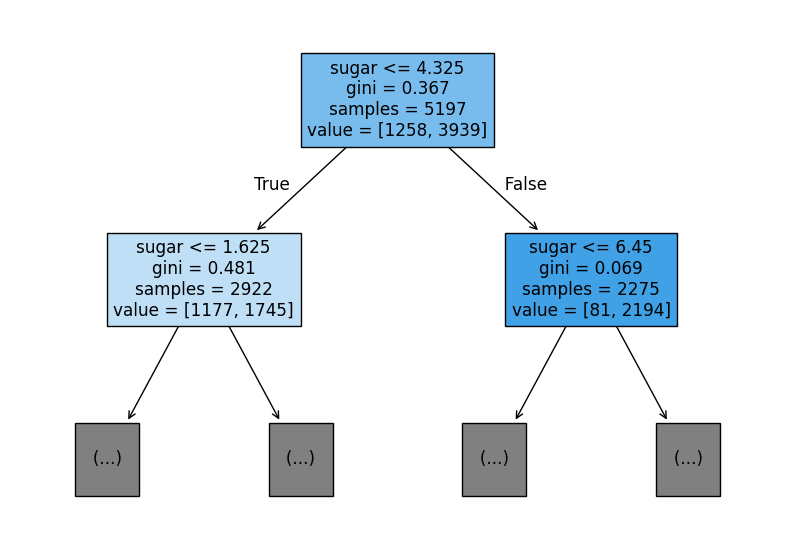

In [13]:
# 결정 트리 시각화
plt.figure(figsize=(10, 7))

plot_tree(dt, max_depth=1, filled=True, feature_names=["alcohol", "sugar", "pH"])
plt.show()

In [15]:
dt1 = DecisionTreeClassifier(max_depth=3)
dt1.fit(train_input, train_target)

print("훈련 데이터", dt1.score(train_input, train_target))
print("테스트 데이터", dt1.score(test_input, test_target))

훈련 데이터 0.8454877814123533
테스트 데이터 0.8415384615384616


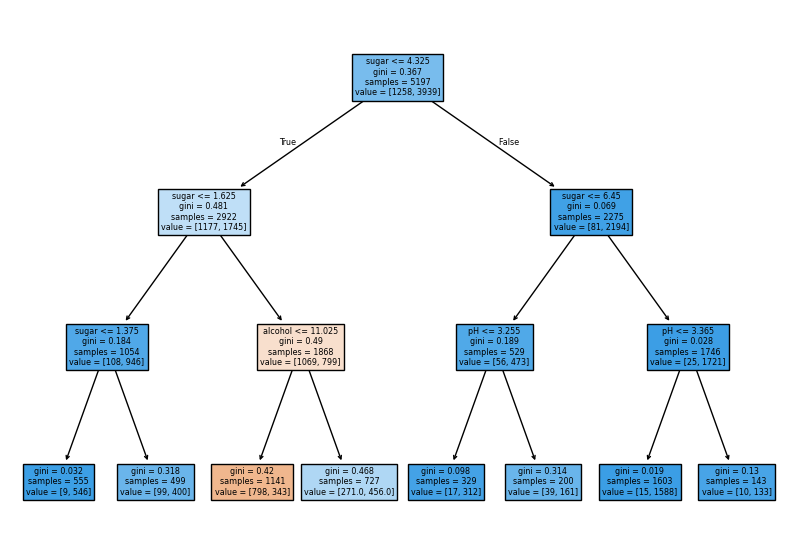

In [17]:
# 결정 트리 시각화
plt.figure(figsize=(10, 7))

plot_tree(dt1, max_depth=3, filled=True, feature_names=["alcohol", "sugar", "pH"])
plt.show()

In [18]:
dt1.feature_importances_

array([0.12345626, 0.86862934, 0.0079144 ])

In [19]:
# 가지치기 최적의 depth를 찾아보는 실험
for depth in [1, 2, 3, 4, 5, 6, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(train_input, train_target)
    tr = dt.score(train_input, train_target)
    te = dt.score(test_input, test_target)
    print(f"max_depth={depth} : train={tr:.4f} test={te:.4f}")

max_depth=1 : train=0.7579 test=0.7377
max_depth=2 : train=0.8099 test=0.7962
max_depth=3 : train=0.8455 test=0.8415
max_depth=4 : train=0.8572 test=0.8485
max_depth=5 : train=0.8672 test=0.8608
max_depth=6 : train=0.8767 test=0.8531
max_depth=None : train=0.9969 test=0.8585
